In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from pathlib import Path
import re
from scipy.ndimage import gaussian_filter1d
from sklearn.decomposition import PCA

In [2]:
dt_folder = Path(r"J:\project_trainingAggression\Data")
neuralDataPaths = [f for f in dt_folder.rglob("*neuralDataFR*.npy")]

rawDataset = dict()

for path in neuralDataPaths:
    search = re.search(r"(\d+)_m(\d+)_obs(\d+)_neuralDataFR*", str(path))
    mouseID = search.group(2)
    obs = search.group(3)

    rawDataset.setdefault(mouseID, {})
    rawDataset[mouseID].setdefault(f"obs{obs}", {})

    rawDataset[mouseID][f"obs{obs}"]["neuralData"] = np.load(path)

    with open(next(path.parent.glob("*behavioralData*.pkl")),"rb") as f:
        behavioralData = pickle.load(f)

    rawDataset[mouseID][f"obs{obs}"]["behavioralData"] = behavioralData

    with open(next(path.parent.glob("*peripheralData*.pkl")),"rb") as f:
        peripheralData = pickle.load(f)

    rawDataset[mouseID][f"obs{obs}"]["peripheralData"] = peripheralData

dtFR = float(re.search(r"(\d+)msBins", path.name).group(1))/1000 #s
fs = 1/dtFR


In [3]:
tmin = 0.0
tmax = 1205.0
bins = np.arange(tmin,tmax,dtFR)

In [4]:
dataset = {"rawData": rawDataset,
           "processedData": {}}

# Combining Left and Right behavioral bouts for the same class

for mouse, mouseData in dataset["rawData"].items():
    dataset["processedData"].setdefault(mouse,{})

    for obs, obsData in mouseData.items():
        dataset["processedData"][mouse].setdefault(obs,{})
        dataset["processedData"][mouse][obs].setdefault("behaviorOnsets", {})

        if obsData["behavioralData"] != None:
            for beh, binArray in obsData["behavioralData"].items():
                onset = (np.where(np.diff(binArray) == 1)[0] + 1).tolist()

                if "Right" in beh:
                    base = beh.split("Right")[0]
                    dataset["processedData"][mouse][obs]["behaviorOnsets"].setdefault(base,[]).extend(onset)
                    dataset["processedData"][mouse][obs]["behaviorOnsets"].setdefault(beh,[]).extend(onset)
                elif "Left" in beh:
                    base = beh.split("Left")[0]
                    dataset["processedData"][mouse][obs]["behaviorOnsets"].setdefault(base,[]).extend(onset)
                    dataset["processedData"][mouse][obs]["behaviorOnsets"].setdefault(beh,[]).extend(onset)
                else:
                    dataset["processedData"][mouse][obs]["behaviorOnsets"].setdefault(beh,[]).extend(onset)

for mouse, mouseData in dataset["processedData"].items():
    for obs, obsData in mouseData.items():
        if obsData["behaviorOnsets"] != None:
            for beh, onsets in obsData["behaviorOnsets"].items():
                obsData["behaviorOnsets"][beh] = np.array(sorted(onsets), dtype=np.int64)

In [5]:
min_gap = 3  # seconds
min_gapSamp = np.argmin(np.abs(bins - min_gap))

for mouse, mouseData in dataset["processedData"].items():
    print(f"\n ============= Mouse:{mouse}  =============")
    for obs, obsData in mouseData.items():
        print(f"   ------------- Obs:{obs}  -------------")

        beh_onsets = obsData.get("behaviorOnsets")
        if beh_onsets == None:
            continue

        merged = {}

        for beh, onsets in beh_onsets.items():
            if len(onsets) == 0:
                merged[beh] = []
                continue

            merged_list = [onsets[0]]

            for onset in onsets[1:]:
                if onset - merged_list[-1] > min_gapSamp:
                    merged_list.append(onset)

            merged[beh] = np.array(merged_list, dtype = np.int64)
            print(f"Original N of trials for {beh}: {len(onsets)} | N after merging: {len(merged_list)} | Difference: {len(onsets) - len(merged_list)}")   

        obsData["mergedBehaviorOnsets"] = merged


 ============= Mouse:975826  =============
   ------------- Obs:obs1  -------------
Original N of trials for attackOfInt: 34 | N after merging: 25 | Difference: 9
Original N of trials for attackOfIntLeft: 32 | N after merging: 25 | Difference: 7
Original N of trials for attackOfIntRight: 2 | N after merging: 2 | Difference: 0
Original N of trials for chaseOfInt: 2 | N after merging: 2 | Difference: 0
Original N of trials for chaseOfIntLeft: 1 | N after merging: 1 | Difference: 0
Original N of trials for chaseOfIntRight: 1 | N after merging: 1 | Difference: 0
Original N of trials for ctBudSniff: 20 | N after merging: 15 | Difference: 5
Original N of trials for lickEmpty: 21 | N after merging: 14 | Difference: 7
Original N of trials for lickMilk: 7 | N after merging: 7 | Difference: 0
Original N of trials for submissionSignFromInt: 52 | N after merging: 38 | Difference: 14
Original N of trials for submissionSignFromIntLeft: 49 | N after merging: 36 | Difference: 13
Original N of trials 

In [ ]:
sigmaBin = 0.7

preStim = -2
postStim = 3

t = np.arange(preStim,postStim+dtFR,dtFR)

preStimSamp = int(preStim/dtFR)
postStimSamp = int(postStim/dtFR)

for mouse, mouseData in dataset["processedData"].items():
    for obs, obsData in mouseData.items():
        obsData.setdefault("neuralData_trials", {})

        for beh, onsets in obsData["mergedBehaviorOnsets"].items():
            if beh == None:
                continue
            
            trial_list = []

            for onset in onsets: 
                nD = dataset["rawData"][mouse][obs]["neuralData"][:, onset+preStimSamp:onset+postStimSamp+1]
                
                mean = np.mean(nD, axis=1, keepdims=True)
                std = np.std(nD, axis=1, keepdims=True)
                std[std == 0] = 1e-8 # Prevents division by zero, generating NaNs in the matrix

                trial = ((nD - mean)/std)
                trial_list.append(gaussian_filter1d(trial,sigmaBin,axis = 1))
                
            obsData["neuralData_trials"][beh] = np.array(trial_list)
            


In [7]:
# PCA sorted Peri-Stimulus Time Histogram (PSTH)

preStimPCA = -0.5
postStimPCA = 1.5

percentile = 90

def plotPSTH_heatmap(savePath, t, preStimPCA, postStimPCA, beh,  PSTH, n_trials, percentile = 90): 

    preStimPCA_samp = np.argmin(np.abs(t - preStimPCA))
    postStimPCA_samp = np.argmin(np.abs(t - postStimPCA))

    pca = PCA(n_components=3)
    scores = pca.fit_transform(PSTH[:,preStimPCA_samp:postStimPCA_samp+1])

    sort_idx = np.argsort(scores[:,0])
    PSTH_sorted = PSTH[sort_idx, :]

    lim = np.percentile(np.abs(PSTH_sorted), 99)

    fig, ax = plt.subplots(1,2, figsize=(15,5)) 

    im = ax[0].imshow(
        PSTH_sorted,
        aspect='auto',
        origin='lower',
        extent=[preStim, postStim, 0, PSTH.shape[0]],
        cmap='jet',
        vmin=-lim,
        vmax=lim)

    ax[0].axvline(0, color='w', linestyle='--')
    ax[0].set_xlabel('Time (s)')
    ax[0].set_ylabel('Neuron')
    ax[0].set_title(f'Mean ({beh}) heatmap | n trials : {n_trials}')
    fig.colorbar(im, ax=ax[0], label='Z scored FR')

    percentile_idx = np.abs(scores[sort_idx,0]) > np.abs(np.percentile(scores[sort_idx,0], 90))
    averPSTH = np.mean(PSTH_sorted[percentile_idx,:], axis = 0)

    ax[1].plot(t, averPSTH, linewidth = 2, color = "r", label = "PSTH")
    ax[1].set_title(f"Mean PSTH of neurons in top {100 - percentile}% of PC1 scores | n = {np.sum(percentile_idx)} neurons")
    ax[1].set_xlabel('Time (s)')
    ax[1].set_ylabel('Z scored FR')
    ax[1].axvline(0, color='k', linestyle='--')
    ax[1].axvspan(preStimPCA, postStimPCA, alpha=0.2, color = "cyan", label = "PCA window")
    ax[1].set_xlim(t[0], t[-1])
    ax[1].legend()

    fig.savefig(savePath, dpi=300, bbox_inches="tight")
    plt.close(fig)
    
    del pca    

In [9]:
psthFolder = dt_folder.parent / "PSTH"
psthFolder.mkdir(exist_ok=True)

for mouse, mouseData in dataset["processedData"].items():
    perMouseFolder = psthFolder / mouse
    perMouseFolder.mkdir(exist_ok=True)
    
    for obs, obsData in mouseData.items():
        perObsFolder = perMouseFolder / obs
        perObsFolder.mkdir(exist_ok=True)

        for beh, neuralData_trials in obsData["neuralData_trials"].items():

            filePath = perObsFolder / f"PSTH_{mouse}_{obs}_{beh}.png"

            if len(np.shape(neuralData_trials)) < 3:
                PSTH = neuralData_trials
            else: 
                PSTH = np.mean(neuralData_trials, axis=0)
            
            n_trials = np.shape(neuralData_trials)[0]
            plotPSTH_heatmap(filePath, t, preStimPCA, postStimPCA, beh, PSTH, n_trials, percentile)

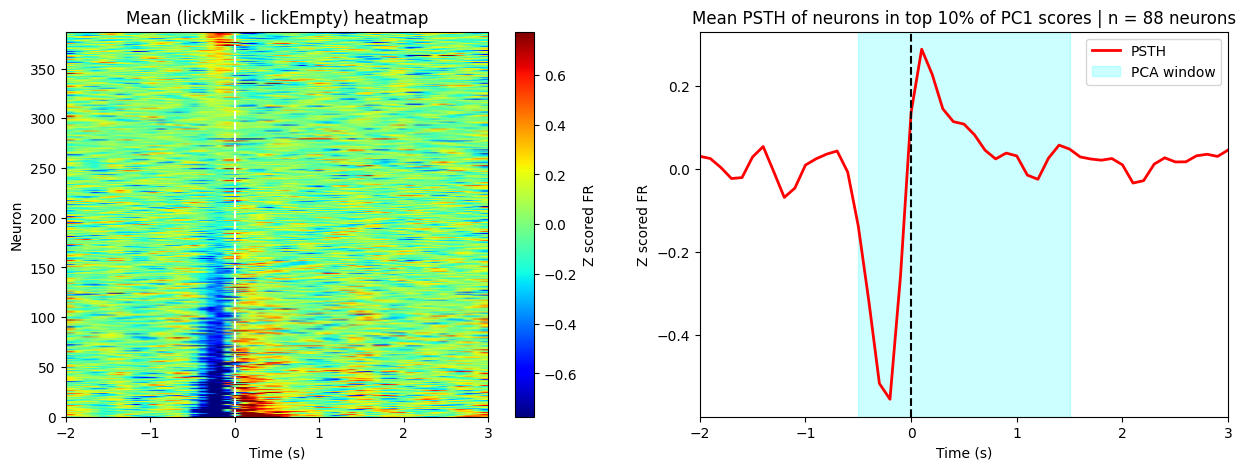

In [222]:
PSTH = np.mean(behavHeatmap["lickMilk"], axis = 0) - np.mean(behavHeatmap["lickEmpty"], axis = 0)
plotPSTH_heatmap(t, preStimPCA, postStimPCA, "lickMilk - lickEmpty", PSTH, percentile)



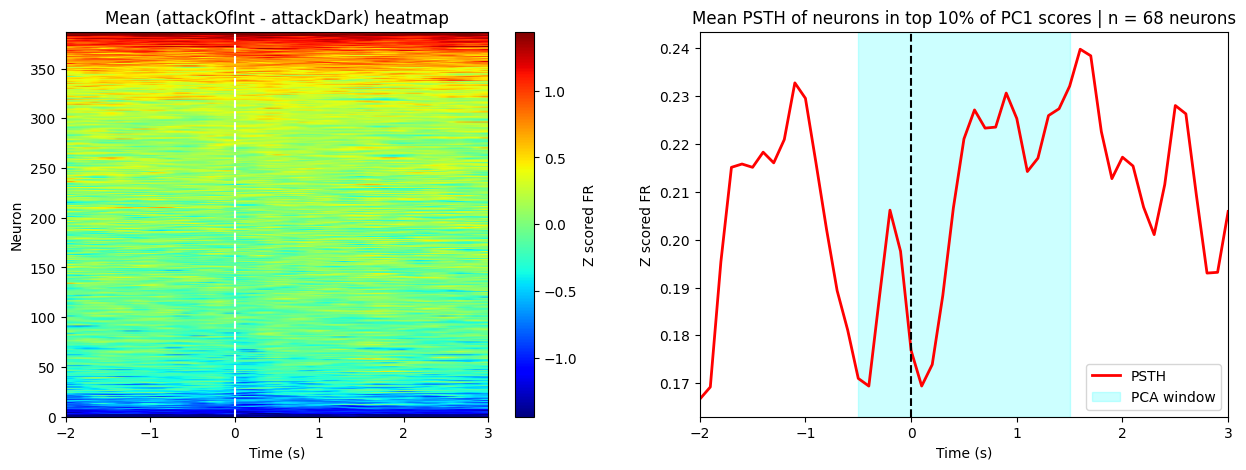

In [223]:
PSTH = np.mean(behavHeatmap["attackOfInt"], axis = 0) - np.mean(behavHeatmap["attackDark"], axis = 0)
plotPSTH_heatmap(t, preStimPCA, postStimPCA, "attackOfInt - attackDark", PSTH, percentile)

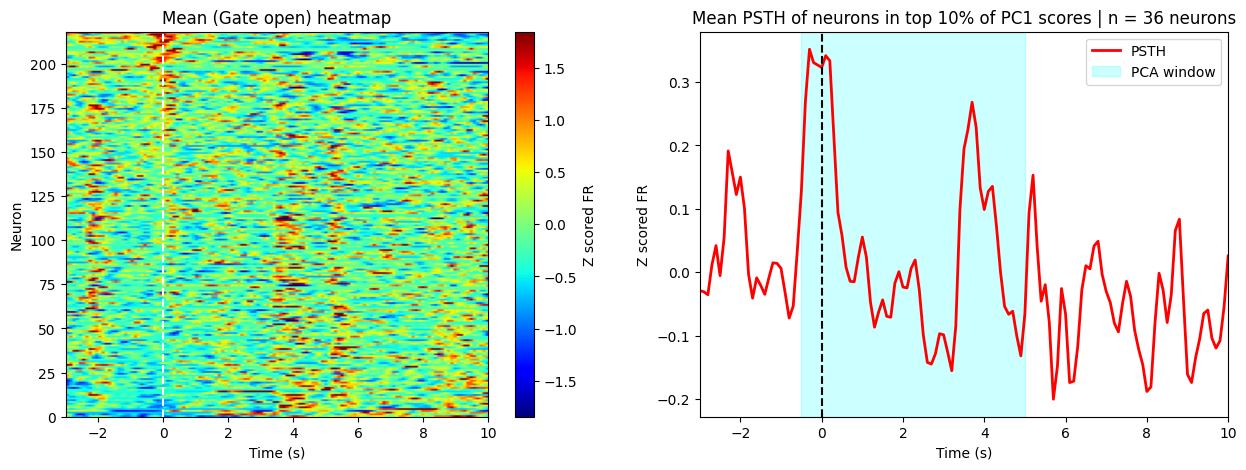

In [276]:
onset = (np.where(np.diff(peripheralData["gateTTL"]) == 1)[0]+1)[0]

preStim = -3
postStim = 10

t = np.arange(preStim,postStim+dtFR,dtFR)

preStimSamp = int(preStim/dtFR)
postStimSamp = int(postStim/dtFR)

mean = np.mean(neuralData[:, onset+preStimSamp:onset+postStimSamp+1], axis=1, keepdims=True)
std = np.std(neuralData[:, onset+preStimSamp:onset+postStimSamp+1], axis=1, keepdims=True)

std[std == 0] = 1

gateAct = gaussian_filter1d((neuralData[:,onset + preStimSamp:onset+postStimSamp+1]-mean)/std,sigmaBin, axis = 1)

preStimPCA = -0.5
postStimPCA = 5

plotPSTH_heatmap(t, preStimPCA, postStimPCA, "Gate open", gateAct, percentile)

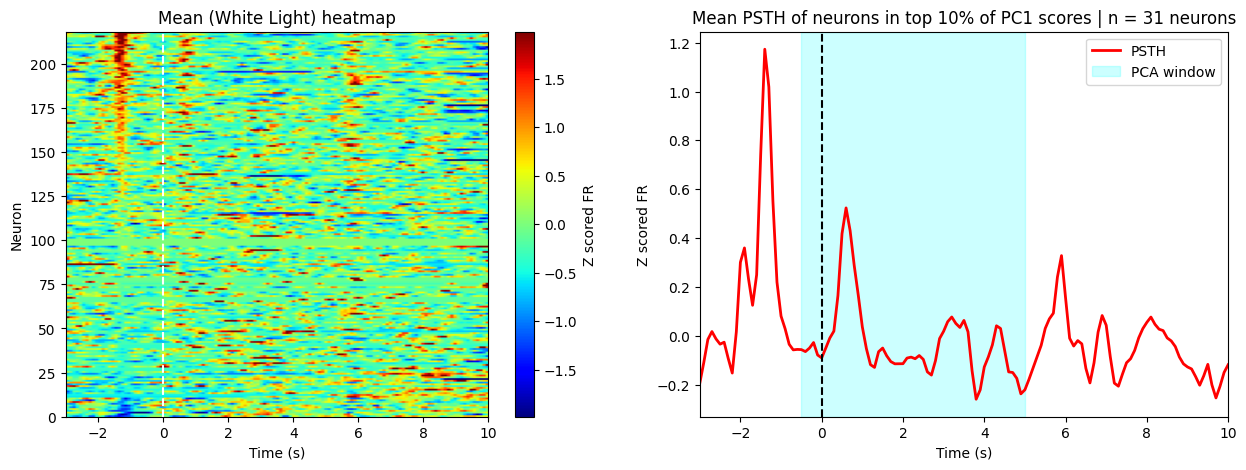

In [277]:
onset = (np.where(np.diff(peripheralData["whiteLightTTL"]) == 1)[0]+1)[0]

preStim = -3
postStim = 10

t = np.arange(preStim,postStim+dtFR,dtFR)

preStimSamp = int(preStim/dtFR)
postStimSamp = int(postStim/dtFR)

mean = np.mean(neuralData[:, onset+preStimSamp:onset+postStimSamp+1], axis=1, keepdims=True)
std = np.std(neuralData[:, onset+preStimSamp:onset+postStimSamp+1], axis=1, keepdims=True)

std[std == 0] = 1

lightAct = gaussian_filter1d((neuralData[:,onset + preStimSamp:onset+postStimSamp+1]-mean)/std,sigmaBin, axis = 1)

preStimPCA = -0.5
postStimPCA = 5

plotPSTH_heatmap(t, preStimPCA, postStimPCA, "White Light", lightAct, percentile)

In [191]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, roc_auc_score
import random

PERCENT_TRAIN = 0.75
KFOLD = 5
random.seed(42)

In [192]:
preStimSamp = preStimPCA_samp
postStimSamp = postStimPCA_samp

t = np.arange(preStim,postStim+dtFR,dtFR)

preStimSamp = int(preStim/dtFR)
postStimSamp = int(postStim/dtFR)

behavHeatmap = dict()
for beh in mergedBehavBouts.keys():
    behavHeatmap[beh] = [zFR[:,onset + preStimSamp:onset+postStimSamp+1] for onset in mergedBehavBouts[beh]]

In [193]:
def GridSearch(method_param_grid, estimator_model, KFOLD, train_data, train_labels, test_data, test_labels):

    modelResults = dict()
    modelResults["Architecture"] = estimator_model
    modelResults["params"] = dict()

    for method, param_grid in method_param_grid.items():
        print(f"\nRunning Grid Search for Classifier architecture: {method}\n")

        modelResults["method"] = method
        
        # Grid searching
        grid_search = GridSearchCV(estimator = estimator_model, 
                                   param_grid = param_grid, 
                                   cv = KFOLD, 
                                   n_jobs = -2)
        
        # ============== Training ============== 

        grid_search.fit(train_data, train_labels)

        # Access the best model's parameters
        best_grid_model = grid_search.best_estimator_
        
        modelResults["params"]["best_model"] = best_grid_model 

        best_index = grid_search.best_index_

        temp_pd = pd.DataFrame(grid_search.cv_results_).iloc[best_index,:]


        # Cross validation scores
        modelResults["params"]["mean_validation_acc"] = temp_pd['mean_test_score']
        modelResults["params"]["std_validation_acc"] = temp_pd['std_test_score'] 
        modelResults["params"]["mean_fit_time"] = temp_pd['mean_fit_time']
 
        # =============== Testing ===============

        pred = best_grid_model.predict(test_data)
        acc = accuracy_score(test_labels, pred)
        modelResults["params"]["test_acc"] = acc
        modelResults["params"]["predictions"] = pred

        prob = best_grid_model.predict_proba(test_data)[:, 1]
        auc = roc_auc_score(test_labels, prob)
        modelResults["params"]["test_auc"] = auc
        modelResults["params"]["probabilities"] = prob

        # Print the best model info  
        print("-------- Best hyperparameter combination --------")
        print("Best parameters:", grid_search.best_params_)
        print(f"Validation accuracy: {grid_search.best_score_} | Testing accuracy: {acc} | Testing AUC: {auc}")

        modelResults["params"]["hyperams"] = grid_search.best_params_

        del grid_search

    return modelResults

In [194]:
# =================== SVM ===================

param_grid_linear = {
    'kernel': ['linear'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 200],
    'tol': [1e-2, 1e-3, 1e-4, 1e-5],  # Tolerance for stopping optimization
    'cache_size': [200],
    'random_state': [42]
}


param_grid_rbf = {
    'kernel': ['rbf'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 200],
    'gamma': ['auto', 'scale', 0.1, 1, 10],  # Specific gamma values
    'tol': [1e-1, 1e-2, 1e-3, 1e-4, 1e-5],
    'cache_size': [200],  # Size of the kernel cache in MB
    'random_state': [42]
}

param_grid_poly = {
    'kernel': ['poly'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 200],
    'gamma': ['auto', 'scale', 0.1, 1, 10],  # Specific gamma values
    'degree': [2, 3],
    'tol': [1e-1, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5],
    'cache_size': [200],
    'random_state': [42]
}

param_grid_sigmoid = {
    'kernel': ['sigmoid'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 200],
    'gamma': ['auto', 'scale', 0.1, 1, 10],  # Specific gamma values
    'tol': [1e-1, 1e-2, 1e-3, 1e-4, 1e-5],
    'cache_size': [200],
    'random_state': [42]
}

svm_param_grid = {
    'linear': param_grid_linear,
    'rbf': param_grid_rbf,
    'poly': param_grid_poly,
    'sigmoid': param_grid_sigmoid,
}

# =================== LDA ===================

param_grid_lda_svd = {
    'solver': ['svd'],
}

param_grid_lda_lsqr = {
    'solver': ['lsqr'],
    'shrinkage': ['auto', None, 0.001],
    'tol': [1e-1, 1e-2, 1e-3, 1e-4, 1e-5],
}

param_grid_lda_eigen = {
    'solver': ['eigen'],
    'shrinkage': ['auto', 0.01, 0.001, 0.0001],
    'tol': [1e-1, 1e-2, 1e-3, 1e-4, 1e-5],
}

# ============= Classifier Grid =============

lda_param_grid = {
    'svd': param_grid_lda_svd,
    #'lsqr': param_grid_lda_lsqr,
    #'eigen': param_grid_lda_eigen,
}

classifiers = [SVC(probability=True), LDA()]

classifier_params = [svm_param_grid, lda_param_grid]

In [195]:
# arrays of shape: (n_trials, n_time, n_neurons)
att_dark = np.array(behavHeatmap["attackDark"])
att_of_int = np.array(behavHeatmap["attackOfInt"])

rng = np.random.default_rng(seed=42)

# match number of negative trials to positive trials
if (att_of_int.shape[0] < att_dark.shape[0]):
    n_pos = att_of_int.shape[0]
else:
    n_pos = att_dark.shape[0]
neg_idx = rng.choice(att_dark.shape[0], size=n_pos, replace=False)

neg_trials = att_dark[neg_idx]     # class 0
pos_trials = att_of_int            # class 1

# shuffle each class independently
neg_perm = rng.permutation(n_pos)
pos_perm = rng.permutation(n_pos)

neg_trials = neg_trials[neg_perm]
pos_trials = pos_trials[pos_perm]

# 75/25 split within each class
n_train = int(PERCENT_TRAIN * n_pos)

X_neg_train = neg_trials[:n_train]
X_neg_test  = neg_trials[n_train:]

X_pos_train = pos_trials[:n_train]
X_pos_test  = pos_trials[n_train:]

# labels
y_neg_train = np.zeros(X_neg_train.shape[0], dtype=int)
y_neg_test  = np.zeros(X_neg_test.shape[0], dtype=int)

y_pos_train = np.ones(X_pos_train.shape[0], dtype=int)
y_pos_test  = np.ones(X_pos_test.shape[0], dtype=int)

# now combine AFTER splitting
X_train = np.concatenate([X_neg_train, X_pos_train], axis=0)
y_train = np.concatenate([y_neg_train, y_pos_train], axis=0)

X_test = np.concatenate([X_neg_test, X_pos_test], axis=0)
y_test = np.concatenate([y_neg_test, y_pos_test], axis=0)

# optional: shuffle train and test sets so class order is mixed
train_perm = rng.permutation(X_train.shape[0])
test_perm = rng.permutation(X_test.shape[0])

X_train = X_train[train_perm]
y_train = y_train[train_perm]

X_test = X_test[test_perm]
y_test = y_test[test_perm]

In [196]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("\n------------------ Classifying attackOfInt vs attackDark ------------------\n")

all_preds = []
all_probs = []

for c_count, clf in enumerate(classifiers):

    model_results = GridSearch(classifier_params[c_count],
                               clf,
                               KFOLD,
                               X_train_flat,
                               y_train,
                               X_test_flat,
                               y_test)


------------------ Classifying attackOfInt vs attackDark ------------------


Running Grid Search for Classifier architecture: linear

-------- Best hyperparameter combination --------
Best parameters: {'C': 0.001, 'cache_size': 200, 'kernel': 'linear', 'random_state': 42, 'tol': 0.01}
Validation accuracy: 1.0 | Testing accuracy: 0.9285714285714286 | Testing AUC: 1.0

Running Grid Search for Classifier architecture: rbf

-------- Best hyperparameter combination --------
Best parameters: {'C': 10, 'cache_size': 200, 'gamma': 'auto', 'kernel': 'rbf', 'random_state': 42, 'tol': 0.1}
Validation accuracy: 1.0 | Testing accuracy: 0.9285714285714286 | Testing AUC: 1.0

Running Grid Search for Classifier architecture: poly

-------- Best hyperparameter combination --------
Best parameters: {'C': 0.001, 'cache_size': 200, 'degree': 2, 'gamma': 0.1, 'kernel': 'poly', 'random_state': 42, 'tol': 0.1}
Validation accuracy: 0.788888888888889 | Testing accuracy: 0.7857142857142857 | Testing AUC: 0.93

In [197]:
def find_zero_runs(x):
    """
    Return contiguous runs where x == 0 as (start, end) pairs.
    end is exclusive.
    """
    x = np.asarray(x)
    is_zero = (x == 0).astype(int)

    # pad so transitions at edges are detected
    diff = np.diff(np.pad(is_zero, (1, 1), constant_values=0))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]

    return list(zip(starts, ends))


def sample_quiet_windows(noStimBouts, window_s=5, buffer_s=10, dtFR=0.1, 
                         n_windows=None, rng=None, allow_overlap=False):
    """
    Sample random windows fully inside noStimBouts == 0 regions,
    while staying at least buffer_s away from any nonzero sample.

    Parameters
    ----------
    noStimBouts : 1D array
        0 means quiet, >=1 means bout/stim present
    window_s : float
        window length in seconds
    buffer_s : float
        minimum distance from any nonzero region, in seconds
    dtFR : float
        sample duration in seconds
    n_windows : int or None
        how many windows to sample; if None, return all possible starts
    rng : np.random.Generator or None
    allow_overlap : bool
        if False, sampled windows will not overlap

    Returns
    -------
    selected_starts : np.ndarray
        sampled onset indices
    selected_windows : list of tuples
        [(start, end_exclusive), ...]
    valid_starts : np.ndarray
        all valid possible onset indices
    """
    if rng is None:
        rng = np.random.default_rng()

    noStimBouts = np.asarray(noStimBouts)

    win_samp = int(round(window_s / dtFR))
    buf_samp = int(round(buffer_s / dtFR))

    zero_runs = find_zero_runs(noStimBouts)

    valid_starts = []

    for run_start, run_end in zero_runs:
        # trim edges by buffer
        valid_start = run_start + buf_samp
        valid_end = run_end - buf_samp  # exclusive boundary for quiet run

        # start index must allow full window to fit
        max_start = valid_end - win_samp

        if valid_start <= max_start:
            valid_starts.extend(range(valid_start, max_start + 1))

    valid_starts = np.array(valid_starts, dtype=int)

    if len(valid_starts) == 0:
        return np.array([], dtype=int), [], valid_starts

    if n_windows is None:
        selected_starts = valid_starts.copy()
    else:
        if allow_overlap:
            n_windows = min(n_windows, len(valid_starts))
            selected_starts = rng.choice(valid_starts, size=n_windows, replace=False)
            selected_starts = np.sort(selected_starts)
        else:
            # greedy random non-overlapping selection
            shuffled = rng.permutation(valid_starts)
            selected = []

            for s in shuffled:
                if all(abs(s - prev) >= win_samp for prev in selected):
                    selected.append(s)
                    if len(selected) >= n_windows:
                        break

            selected_starts = np.sort(np.array(selected, dtype=int))

    selected_windows = [(s, s + win_samp) for s in selected_starts]

    return selected_starts, selected_windows, valid_starts

In [198]:
rng = np.random.default_rng(seed=42)


noStimBouts = 0

for beh in behavioralData.keys():
    noStimBouts += behavioralData[beh]

# noStimBouts should be 1D, same time base as your zFR / behavioral vectors
selected_starts, selected_windows, valid_starts = sample_quiet_windows(
    noStimBouts=noStimBouts,
    window_s=5,
    buffer_s=5,
    dtFR=dtFR,
    n_windows=n_pos,      # or len(att_dark), len(att_of_int), etc.
    rng=rng,
    allow_overlap=False
)

print("Number of valid possible windows:", len(valid_starts))
print("Number of sampled windows:", len(selected_windows))

Number of valid possible windows: 3499
Number of sampled windows: 28


In [204]:
np.shape(X_neg_train)

(21, 387, 51)

In [199]:
quietBouts = []
att_of_int = np.array(behavHeatmap["attackOfInt"])

for win in selected_windows:
    quietBouts.append(zFR[:,win[0]:win[1]+1])

rng = np.random.default_rng(seed=42)

neg_idx = rng.choice(np.array(quietBouts).shape[0], size=n_pos, replace=False)
neg_trials = np.array(quietBouts)[neg_idx]   # class 0
pos_trials = att_of_int            # class 1

# shuffle each class independently
neg_perm = rng.permutation(n_pos)
pos_perm = rng.permutation(n_pos)

neg_trials = neg_trials[neg_perm]
pos_trials = pos_trials[pos_perm]

# 75/25 split within each class
n_train = int(PERCENT_TRAIN * n_pos)

X_neg_train = neg_trials[:n_train]
X_neg_test  = neg_trials[n_train:]

X_pos_train = pos_trials[:n_train]
X_pos_test  = pos_trials[n_train:]

# labels
y_neg_train = np.zeros(X_neg_train.shape[0], dtype=int)
y_neg_test  = np.zeros(X_neg_test.shape[0], dtype=int)

y_pos_train = np.ones(X_pos_train.shape[0], dtype=int)
y_pos_test  = np.ones(X_pos_test.shape[0], dtype=int)

# now combine AFTER splitting
X_train = np.concatenate([X_neg_train, X_pos_train], axis=0)
y_train = np.concatenate([y_neg_train, y_pos_train], axis=0)

X_test = np.concatenate([X_neg_test, X_pos_test], axis=0)
y_test = np.concatenate([y_neg_test, y_pos_test], axis=0)

# optional: shuffle train and test sets so class order is mixed
train_perm = rng.permutation(X_train.shape[0])
test_perm = rng.permutation(X_test.shape[0])

X_train = X_train[train_perm]
y_train = y_train[train_perm]

X_test = X_test[test_perm]
y_test = y_test[test_perm]

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 2, the array at index 0 has size 51 and the array at index 1 has size 131

In [200]:
np.shape(X_train)

(42, 387, 131)

In [201]:
np.shape(X_test)

(14, 387, 131)

In [ ]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("\n------------------ Classifying attackOfInt vs randomBouts ------------------\n")

all_preds = []
all_probs = []

for c_count, clf in enumerate(classifiers):

    model_results = GridSearch(classifier_params[c_count],
                               clf,
                               KFOLD,
                               X_train_flat,
                               y_train,
                               X_test_flat,
                               y_test)


------------------ Classifying attackOfInt vs randomBouts ------------------


Running Grid Search for Classifier architecture: linear

-------- Best hyperparameter combination --------
Best parameters: {'C': 0.001, 'cache_size': 200, 'kernel': 'linear', 'random_state': 42, 'tol': 0.01}
Validation accuracy: 0.7 | Testing accuracy: 0.9 | Testing AUC: 1.0

Running Grid Search for Classifier architecture: rbf

-------- Best hyperparameter combination --------
Best parameters: {'C': 10, 'cache_size': 200, 'gamma': 'scale', 'kernel': 'rbf', 'random_state': 42, 'tol': 0.01}
Validation accuracy: 0.7733333333333334 | Testing accuracy: 0.9 | Testing AUC: 1.0

Running Grid Search for Classifier architecture: poly

-------- Best hyperparameter combination --------
Best parameters: {'C': 0.001, 'cache_size': 200, 'degree': 2, 'gamma': 0.1, 'kernel': 'poly', 'random_state': 42, 'tol': 0.1}
Validation accuracy: 0.7466666666666667 | Testing accuracy: 0.7 | Testing AUC: 0.92

Running Grid Search for 

In [ ]:
quietBouts = []
att_dark = np.array(behavHeatmap["attackDark"])

for win in selected_windows:
    quietBouts.append(zFR[:,win[0]:win[1]+1])

rng = np.random.default_rng(seed=42)

neg_idx = rng.choice(np.array(quietBouts).shape[0], size=n_pos, replace=False)
neg_trials = np.array(quietBouts)[neg_idx]   # class 0
pos_trials = att_dark            # class 1

# shuffle each class independently
neg_perm = rng.permutation(n_pos)
pos_perm = rng.permutation(n_pos)

neg_trials = neg_trials[neg_perm]
pos_trials = pos_trials[pos_perm]

# 75/25 split within each class
n_train = int(PERCENT_TRAIN * n_pos)

X_neg_train = neg_trials[:n_train]
X_neg_test  = neg_trials[n_train:]

X_pos_train = pos_trials[:n_train]
X_pos_test  = pos_trials[n_train:]

# labels
y_neg_train = np.zeros(X_neg_train.shape[0], dtype=int)
y_neg_test  = np.zeros(X_neg_test.shape[0], dtype=int)

y_pos_train = np.ones(X_pos_train.shape[0], dtype=int)
y_pos_test  = np.ones(X_pos_test.shape[0], dtype=int)

# now combine AFTER splitting
X_train = np.concatenate([X_neg_train, X_pos_train], axis=0)
y_train = np.concatenate([y_neg_train, y_pos_train], axis=0)

X_test = np.concatenate([X_neg_test, X_pos_test], axis=0)
y_test = np.concatenate([y_neg_test, y_pos_test], axis=0)

# optional: shuffle train and test sets so class order is mixed
train_perm = rng.permutation(X_train.shape[0])
test_perm = rng.permutation(X_test.shape[0])

X_train = X_train[train_perm]
y_train = y_train[train_perm]

X_test = X_test[test_perm]
y_test = y_test[test_perm]

In [ ]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("\n------------------ Classifying attackDark vs randomBouts ------------------\n")

all_preds = []
all_probs = []

for c_count, clf in enumerate(classifiers):

    model_results = GridSearch(classifier_params[c_count],
                               clf,
                               KFOLD,
                               X_train_flat,
                               y_train,
                               X_test_flat,
                               y_test)


------------------ Classifying attackDark vs randomBouts ------------------


Running Grid Search for Classifier architecture: linear

-------- Best hyperparameter combination --------
Best parameters: {'C': 0.001, 'cache_size': 200, 'kernel': 'linear', 'random_state': 42, 'tol': 0.01}
Validation accuracy: 0.7866666666666667 | Testing accuracy: 0.7 | Testing AUC: 0.6000000000000001

Running Grid Search for Classifier architecture: rbf

-------- Best hyperparameter combination --------
Best parameters: {'C': 10, 'cache_size': 200, 'gamma': 'auto', 'kernel': 'rbf', 'random_state': 42, 'tol': 0.1}
Validation accuracy: 0.7866666666666667 | Testing accuracy: 0.7 | Testing AUC: 0.76

Running Grid Search for Classifier architecture: poly

-------- Best hyperparameter combination --------
Best parameters: {'C': 0.001, 'cache_size': 200, 'degree': 2, 'gamma': 0.1, 'kernel': 'poly', 'random_state': 42, 'tol': 0.1}
Validation accuracy: 0.6933333333333334 | Testing accuracy: 0.6 | Testing AUC: 0.